In [1]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scripts import material_params as mat
from scipy.linalg import eigh
import plotly.graph_objects as go
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

In [2]:
nodes = []
nodal_values = np.loadtxt('../text_files/nodes_minimal_model.txt', delimiter=',')
theta = -13 # degrees

nodal_values[:, 1] = nodal_values[:, 1] * np.cos(np.radians(theta)) - nodal_values[:, 2] * np.sin(np.radians(theta))
nodal_values[:, 2] = nodal_values[:, 1] * np.sin(np.radians(theta)) + nodal_values[:, 2] * np.cos(np.radians(theta))

for i in range(nodal_values.shape[0]):
  nodes.append(n.nodes(nodal_values[i, 0], nodal_values[i, 1], nodal_values[i, 2]))

# **Primary truss parameters**

In [3]:
# Truss parameters
E = 210e9  # Young's modulus in Pascals
nu = 0.3   # Poisson's ratio
G = E / (2 * (1 + nu))  # Shear modulus in Pascals
m = 6.7504 * 10 ** 6 #kg
m = 5596024
d1 = 0.8 #m
d2 = 1.8 #m
t1 = 0.03 #m
t2 = 0.08 #m
L_truss_element_y = 15 #m
h_truss = 18 #m
Aeq, Ieqy, Ieqz, b_eq, h_eq = mat.effective_truss_stiffness(d1, d2, t1, t2, h_truss, L_truss_element_y) 
L = 237.5
rho_truss = m / (L * Aeq)
It = (b_eq * h_eq**3 / 3) * (1 - 0.63 * (h_eq / b_eq) * (1 - (h_eq**4 / (12 * b_eq**4)))) *0.06
k = 0.08
Ip  = Ieqy + Ieqz
ep_K = [E, G, Aeq, Ieqy, Ieqz, It, k]
ep_m = [rho_truss, Aeq, Ieqy, Ieqz, Ip]

# **Fenders, connecting elements and retaining wall parameters**

In [4]:
k = 5/6
rho = 7850 #kg/m^3
E=210e9 #Pa
G = E/(2*(1+nu)) #Pa
nu = 0.3 #Poisson's ratio
k_fender =  mat.stiffness_fenders()
Iy_connect, Iz_connect, Ip_connect, It_connect, A_connect = mat.stiffness_connecting_beams()
ep_K_connect = [E, G, A_connect, Iy_connect, Iz_connect, It_connect, k]
ep_m_connect = [rho, A_connect, Iy_connect, Iz_connect, Ip_connect]



h_eq = 22
Iy_wall = 1250
Iz_wall = 0.25 * Iy_wall
Ip_wall = Iy_wall + Iz_wall
It_wall = 0.05 * Iy_wall
A_wall = Iy_wall * 12 / h_eq**2
m_wall = 6455148
L_wall = 237.5
rho_wall = m_wall / (L_wall * A_wall)
ep_K_wall = [E, G, A_wall, Iy_wall, Iz_wall, It_wall, k]
ep_m_wall = [rho_wall, A_wall, Iy_wall, Iz_wall, Ip_wall]


# **Connecting truss parameters**

In [5]:
A_eq, Iy_eq, Iz_eq, b_eq, h_eq = mat.stiffness_connecting_truss(d1, d2, t1, t2, h_truss, L_truss_element_y)
Ip_connecting_truss = Iy_eq + Iz_eq 
It_eq = (b_eq * h_eq**3 / 3) * (1 - 0.63 * (h_eq / b_eq) * (1 - (h_eq**4 / (12 * b_eq**4)))) *0.06
ep_K_connecting_truss = [E, G, A_eq, Iy_eq, Iz_eq, It_eq, k]
ep_m_connecting_truss = [rho_truss, A_eq, Iy_eq, Iz_eq, Ip_connect]

# **Braces parameters**

In [6]:
k = 5/6
Iy, Iz, Ip, It, A = mat.stiffness_braces()
ep_K_braces = [E, G, A, Iy, Iz, It, k]
ep_m_braces = [rho, A, Iy, Iz, Ip]

# **Assembling the material properties to the correct elements**

In [7]:
elements = []
element_nodes = np.loadtxt('../text_files/element_nodes_OP3.txt', dtype=int)
for i in range(element_nodes.shape[0]):
    if element_nodes[i, 2] == 0:
        elements.append(e.elements_wet(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K, ep_m, theta))

    elif element_nodes[i, 2] == 1:
        elements.append(e.elements_added_mass_wet(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_wall, ep_m_wall, theta))
    elif element_nodes[i, 2] == 2:
        elements.append(e.elements_wet(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_connect, ep_m_connect, theta))
    elif element_nodes[i, 2] == 3:
        elements.append(e.elements_wet(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_connecting_truss, ep_m_connecting_truss, theta))   
    elif element_nodes[i, 2] == 4:
        elements.append(e.elements_wet(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_braces, ep_m_braces, theta))
    elif element_nodes[i, 2] == 5:
        elements.append(e.elements_added_mass_truss(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K, ep_m, theta))
element_nodes = element_nodes[:, :2] # Remove the column with element type information


dofs = n.degrees_of_freedom(nodes)

element_locs = []

for (nA, nB) in element_nodes:
    dofs_A = dofs[f'dof_{nA}']
    dofs_B = dofs[f'dof_{nB}']
    element_locs.append(np.hstack((dofs_A, dofs_B)))

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


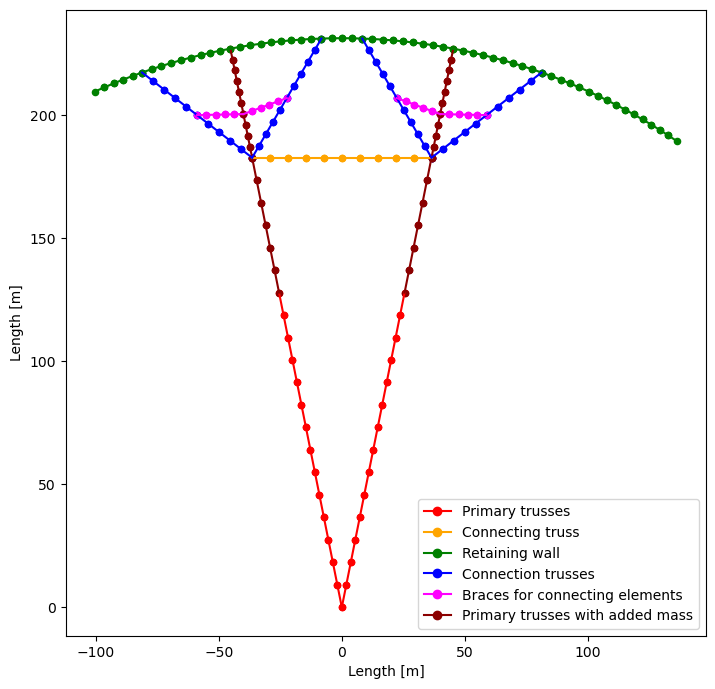

In [8]:


def plot_elements2d(elements):

    fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=False)

    for i, element in enumerate(elements):
        n1, n2, _, _ = element
        x = [n1[0], n2[0]]
        y = [n1[1], n2[1]]

        if i > 13 and i < 30:
            color = 'darkred'
        elif i > 43 and i < 60:
            color = 'darkred'
        elif i < 60:
            color = 'red'
        elif i < 70:
            color = 'orange'
        elif i < 130:
            color = 'green'
        elif i < 170:
            color = 'blue'
        else:
            color = 'magenta'

        ax.plot(x, y, color=color)
        ax.scatter(*n1[:2], color=color, s=20)
        ax.scatter(*n2[:2], color=color, s=20)

    for i, element in enumerate(elements):
        n1, n2, _, _ = element

        if i in [130, 140, 150, 160, 170, 185]:
            ax.scatter(*n1[:2], color='darkred', s=20)

        if i in [139, 149, 159, 169]:
            ax.scatter(*n2[:2], color='green', s=20)

    legend_handles = [
        Line2D([0], [0], color='red', marker='o', markersize=6, label='Primary trusses'),
        Line2D([0], [0], color='orange', marker='o', markersize=6, label='Connecting truss'),
        Line2D([0], [0], color='green', marker='o', markersize=6, label='Retaining wall'),
        Line2D([0], [0], color='blue', marker='o', markersize=6,
               label='Connection trusses'),
        Line2D([0], [0], color='magenta', marker='o', markersize=6,
               label='Braces for connecting elements'),
        Line2D([0], [0], color='darkred', marker='o', markersize=6,
               label='Primary trusses with added mass')
    ]

    ax.legend(handles=legend_handles, loc='lower right', frameon=True)
    ax.set_xlabel('Length [m]')
    ax.set_ylabel('Length [m]')
    ax.set_aspect('equal')

    # IMPORTANT: same fixed geometry
    ax.set_position([0.1, 0.1, 0.8, 0.8])

    fig.savefig('../../elements_2d_addedmass.eps', format='eps')
    plt.show()
    plt.close(fig)

plot_elements2d(elements)

# **Assemble global mass and stiffness matrix**

In [9]:
N = len(nodes)
DOFS_per_node = 6



K_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))
M_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))

K_locs = []
M_locs = []



for i in range(len(element_locs)):
    K_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-1]
    M_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-2]



# To restore symmetry of the global stiffness and mass matrices
K_global = 0.5 * (K_global + K_global.T)
M_global = 0.5 * (M_global + M_global.T)



In [10]:
fender_dofs =  [70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 99,
               100, 102, 104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124,
               126, 128]
fender_dofs = [70, 75, 79, 83, 87, 91, 95, 99, 103, 107, 111, 115, 119, 123, 128]

k_fender_dofs = [dofs[f'dof_{i+1}'][2] for i in fender_dofs]
for dof in k_fender_dofs:
    K_global[dof, dof] += k_fender



In [11]:
indices_to_remove = np.hstack((dofs['dof_1'][0:3], dofs['dof_129'][0:2]))
keep_indices = np.setdiff1d(np.arange(N * DOFS_per_node), indices_to_remove)
K_global_reduced = K_global[np.ix_(keep_indices, keep_indices)]
M_global_reduced = M_global[np.ix_(keep_indices, keep_indices)]

In [12]:
eigvals_global, eigvecs_global = eigh(K_global_reduced, M_global_reduced)


tol = 1e-6
positive = eigvals_global > tol
eigvals_global = eigvals_global[positive]
eigvecs_global = eigvecs_global[:, positive]

frequencies_rad = np.sqrt(eigvals_global)
frequencies_hz = frequencies_rad / (2 * np.pi)


data_freqs = pd.DataFrame({
    'Frequency (Hz)': frequencies_hz,
    'Frequency (rad/s)': frequencies_rad
})

display(data_freqs[:15])


,Frequency (Hz),Frequency (rad/s)
0,0.260958,1.639645
1,0.314929,1.978755
2,1.213466,7.624434
3,1.310806,8.236038
4,1.505331,9.458276
5,1.623611,10.201451
6,1.850007,11.623940
7,1.865293,11.719981
8,1.872194,11.763343
9,2.111921,13.269590


In [13]:
eigvecs_full = e.expand_eigenvectors(eigvecs_global, keep_indices, N*DOFS_per_node)
print("Expanded eigenvectors shape:", eigvecs_global.shape)
np.save('../text_files/canal_eigvecs_global.npy', eigvecs_full)

Expanded eigenvectors shape: (1081, 1081)


In [14]:
eigvecs_disp_full = e.extract_displacement(eigvecs_full, keep=3, skip=3)
eigvecs_full.shape


(1086, 1081)

In [15]:
import numpy as np
import plotly.graph_objects as go

# ---------------- COLOR RULES (MATCHING MATPLOTLIB) ----------------
def element_color(i):
    # darkred elements
    if (i > 13 and i < 30) or (i > 43 and i < 60):
        return "darkred"
    # remaining <60 are red
    elif i < 60:
        return "red"
    elif i < 70:
        return "orange"
    elif i < 130:
        return "green"
    elif i < 169:
        return "blue"
    else:
        return "magenta"

element_colors = [element_color(i) for i in range(len(element_nodes))]

# ---------------- NODE COLORS (MATCHING SPECIAL EXCEPTIONS) ----------------
node_colors = ["black"] * len(nodes)

for i, (nA, nB) in enumerate(element_nodes):

    col = element_colors[i]

    # Base color following element color
    node_colors[nA - 1] = col
    node_colors[nB - 1] = col

    # Special overrides (same as Matplotlib snippet)
    if i in [130, 140, 150, 160]:
        node_colors[nA - 1] = "darkred"

    if i in [139, 149, 159, 169]:
        node_colors[nB - 1] = "green"

    if i in [170, 185]:
        node_colors[nA - 1] = "darkred"


# ---------------- SETTINGS ----------------
modes_to_plot = 10
scale = 100000

nodes = np.array(nodes)
eigvecs_disp_full = np.array(eigvecs_disp_full)

# FIXED AXES (ZOOMED IN VERSION)
min_x, max_x = nodes[:,0].min(), nodes[:,0].max()
min_y, max_y = nodes[:,1].min(), nodes[:,1].max()
min_z, max_z = nodes[:,2].min(), nodes[:,2].max()

Lmax = max(max_x-min_x, max_y-min_y, max_z-min_z)

mid_x = (min_x + max_x)/2
mid_y = (min_y + max_y)/2
mid_z = (min_z + max_z)/2

zoom = 0.7 * Lmax

xr = [mid_x - zoom, mid_x + zoom]
yr = [mid_y - zoom, mid_y + zoom]
zr = [mid_z - zoom, mid_z + zoom]


# ==========================================================
# LOOP OVER MODES
# ==========================================================
for i in range(modes_to_plot):

    mode_disp = eigvecs_disp_full[:, i].reshape(-1, 3)
    U = nodes + scale * mode_disp

    traces = []

    # ======================================================
    # REFERENCE PLANE (15° downward tilt)
    # ======================================================
    x_grid = np.linspace(-130, 150, 50)
    y_grid = np.linspace(-10, 270, 50)
    Xg, Yg = np.meshgrid(x_grid, y_grid)
    Zg = np.zeros_like(Xg)

    theta = np.radians(-13)
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta),  np.cos(theta)]
    ])

    plane_points = np.vstack([Xg.flatten(), Yg.flatten(), Zg.flatten()])
    rotated = Rx @ plane_points

    Xg_rot = rotated[0].reshape(Xg.shape)
    Yg_rot = rotated[1].reshape(Yg.shape)
    Zg_rot = rotated[2].reshape(Zg.shape)

    traces.append(
        go.Surface(
            x=Xg_rot, y=Yg_rot, z=Zg_rot,
            showscale=False, opacity=0.25,
            colorscale=[[0, "rgb(170,170,170)"], [1, "rgb(170,170,170)"]],
            hoverinfo="skip"
        )
    )

    # ======================================================
    # UNDEFORMED STRUCTURE
    # ======================================================
    for e, (nA, nB) in enumerate(element_nodes):
        p1 = nodes[nA - 1]
        p2 = nodes[nB - 1]

        traces.append(
            go.Scatter3d(
                x=[p1[0], p2[0]],
                y=[p1[1], p2[1]],
                z=[p1[2], p2[2]],
                mode="lines",
                line=dict(color="lightgrey", width=6),
                opacity=0.35,
                showlegend=False
            )
        )

    # ======================================================
    # DEFORMED STRUCTURE
    # ======================================================
    for e, (nA, nB) in enumerate(element_nodes):
        p1 = U[nA - 1]
        p2 = U[nB - 1]

        traces.append(
            go.Scatter3d(
                x=[p1[0], p2[0]],
                y=[p1[1], p2[1]],
                z=[p1[2], p2[2]],
                mode="lines",
                line=dict(color=element_colors[e], width=4),
                opacity=0.95,
                showlegend=False
            )
        )

    # ======================================================
    # NODES (COLORED BY RULES)
    # ======================================================
    traces.append(
        go.Scatter3d(
            x=U[:,0],
            y=U[:,1],
            z=U[:,2],
            mode="markers",
            marker=dict(size=3, color=node_colors),
            showlegend=False
        )
    )

    # ======================================================
    # LEGEND (MATCHING YOUR MATPLOTLIB VERSION)
    # ======================================================
    legend_traces = [
        go.Scatter3d(x=[None], y=[None], z=[None], mode="lines",
                     line=dict(color="red", width=4),
                     name="Primary trusses"),

        go.Scatter3d(x=[None], y=[None], z=[None], mode="lines",
                     line=dict(color="darkred", width=4),
                     name="Primary trusses with added mass"),

        go.Scatter3d(x=[None], y=[None], z=[None], mode="lines",
                     line=dict(color="orange", width=4),
                     name="Connecting truss"),

        go.Scatter3d(x=[None], y=[None], z=[None], mode="lines",
                     line=dict(color="green", width=4),
                     name="Retaining wall"),

        go.Scatter3d(x=[None], y=[None], z=[None], mode="lines",
                     line=dict(color="blue", width=4),
                     name="Connection trusses and retaining wall"),

        go.Scatter3d(x=[None], y=[None], z=[None], mode="lines",
                     line=dict(color="magenta", width=4),
                     name="Bracing elements")
    ]

    fig = go.Figure(data=traces + legend_traces)

    # ======================================================
    # LAYOUT
    # ======================================================
    fig.update_layout(
        width=950,
        height=750,
        paper_bgcolor="white",
        showlegend=True,
        legend=dict(
            x=0.45, y=0.95,
            bgcolor="rgba(255,255,255,0.85)",
            bordercolor="lightgrey",
            borderwidth=1
        ),
        scene=dict(
            xaxis=dict(title="X (m)", range=xr, showbackground=False),
            yaxis=dict(title="Y (m)", range=yr, showbackground=False),
            zaxis=dict(title="Z (m)", range=zr, showbackground=False),
            aspectmode="manual",
            aspectratio=dict(x=1, y=1, z=1),
            camera=dict(eye=dict(x=1, y=1, z=0.7))
        ),
        margin=dict(l=10, r=10, b=10, t=60)
    )

    fig.show()
